In [164]:
import tensorflow as tf
import h5py
import numpy as np
from matplotlib.pyplot import imshow
import matplotlib.pyplot as plt

<h3>Creating a binary classifier using TensorFlow keras sequantial API</h3>

In [98]:
def binary_classifier():

    model = tf.keras.Sequential([

        tf.keras.layers.ZeroPadding2D(padding=(3, 3), input_shape=(64, 64, 3)),
        tf.keras.layers.Conv2D(filters=32, kernel_size=(7, 7), strides=(1, 1)),
        tf.keras.layers.BatchNormalization(axis=3),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding="valid"),
        tf.keras.layers.Flatten(data_format="channels_last"),
        tf.keras.layers.Dense(units=1, activation="sigmoid")   
        
    ])

    return model    

In [99]:
first_model = binary_classifier()
first_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ zero_padding2d_9                │ (None, 70, 70, 3)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │        32,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,633 (147.00 KB)

 Trainable params: 37,569 (146.75 KB)

 Non-trainable params: 64 (256.00 B)

In [100]:
def train(model, X_train, Y_train, X_test=None, Y_test=None, epochs=100, batch_size=32, learning_rate=1e-3):

    model.summary()
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    history = model.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, Y_test) if X_test is not None and Y_test is not None else None)
    
    training_loss = history.history['loss']
    training_accuracy = history.history['accuracy']
    
    evaluation_results = {'training_loss': training_loss, 'training_accuracy': training_accuracy}
    
    if X_test is not None and Y_test is not None:
        test_loss, test_accuracy = model.evaluate(X_test, Y_test)
        evaluation_results['test_loss'] = test_loss
        evaluation_results['test_accuracy'] = test_accuracy
    
    return evaluation_results   

<h4>Train the Model</h4>

In [101]:
train_data = h5py.File("/home/samani/Documents/projects/deep-learning/data/train_happy.h5", "r")
test_data = h5py.File("/home/samani/Documents/projects/deep-learning/data/test_happy.h5", "r")

In [102]:
print(train_data.keys())
print(test_data.keys())

<KeysViewHDF5 ['list_classes', 'train_set_x', 'train_set_y']>
<KeysViewHDF5 ['list_classes', 'test_set_x', 'test_set_y']>


In [103]:
print(train_data["list_classes"])
print(test_data["list_classes"])

<HDF5 dataset "list_classes": shape (2,), type "<i8">
<HDF5 dataset "list_classes": shape (2,), type "<i8">


In [104]:
X_train = train_data["train_set_x"]
X_test = test_data["test_set_x"]
Y_train = train_data["train_set_y"]
Y_test = test_data["test_set_y"]

In [105]:
print(X_train.shape)
print(X_test.shape)

(600, 64, 64, 3)
(150, 64, 64, 3)


In [106]:
X_train = np.array(list(X_train))
X_test = np.array(list(X_test))

X_train = X_train / 255.
X_test = X_test / 255.

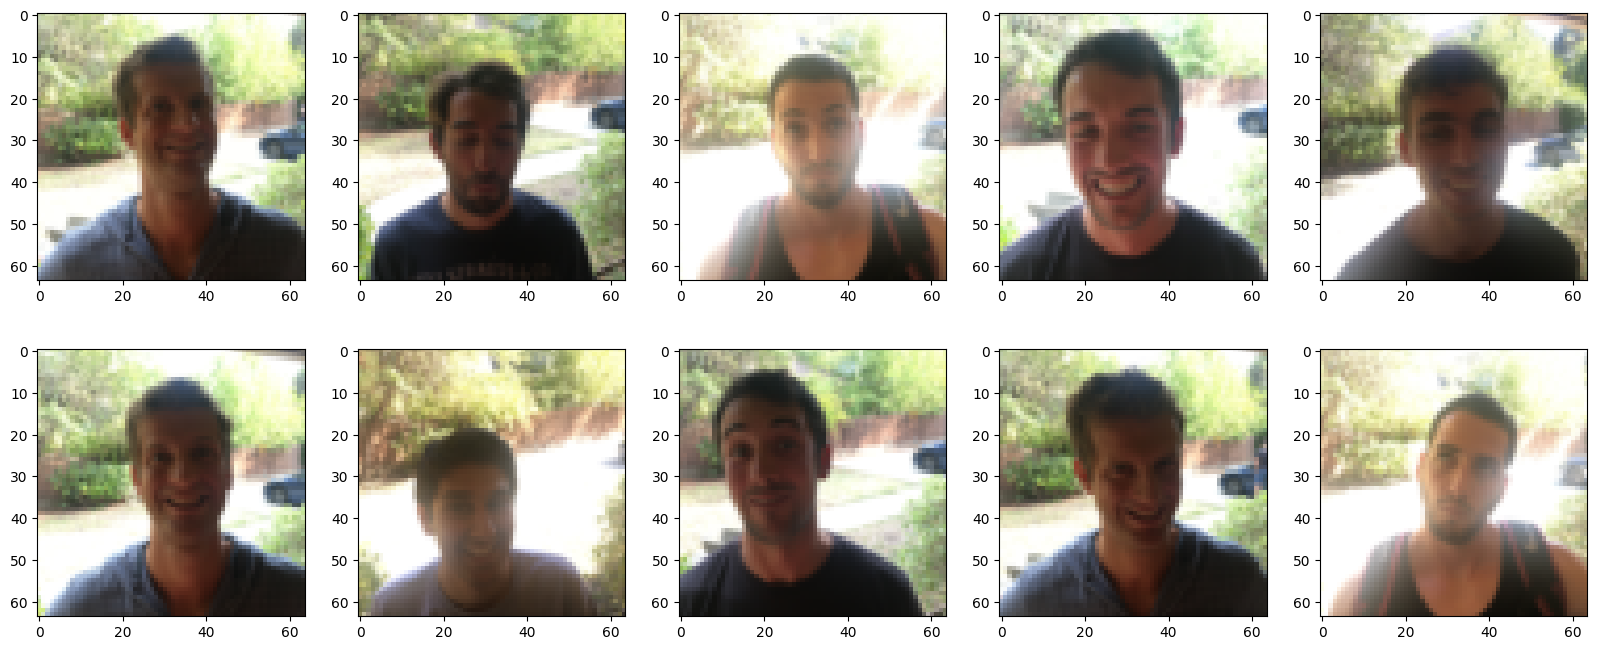

In [107]:
plt.figure(figsize=(20, 8))
plt.subplot(2, 5, 1)
imshow(X_train[1])
plt.subplot(2, 5, 2)
imshow(X_train[6])
plt.subplot(2, 5, 3)
imshow(X_train[8])
plt.subplot(2, 5, 4)
imshow(X_train[12])
plt.subplot(2, 5, 5)
imshow(X_train[14])
plt.subplot(2, 5, 6)
imshow(X_train[98])
plt.subplot(2, 5, 7)
imshow(X_train[57])
plt.subplot(2, 5, 8)
imshow(X_train[123])
plt.subplot(2, 5, 9)
imshow(X_train[187])
plt.subplot(2, 5, 10)
imshow(X_train[567])
plt.show()

In [67]:
print(Y_train.shape)
print(Y_test.shape)

(600,)
(150,)


In [68]:
print(Y_train[:20])

[0 1 1 1 1 1 0 0 0 1 0 0 1 1 1 1 1 0 0 0]


In [69]:
results = train(model=first_model, X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test, epochs=40, batch_size=16, learning_rate=1e-6)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ zero_padding2d_7                │ (None, 70, 70, 3)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │        32,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,773 (440.52 KB)

 Trainable params: 37,569 (146.75 KB)

 Non-trainable params: 64 (256.00 B)

 Optimizer params: 75,140 (293.52 KB)

Epoch 1/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9530 - loss: 0.1861 - val_accuracy: 0.9600 - val_loss: 0.1237
Epoch 2/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9749 - loss: 0.0736 - val_accuracy: 0.9400 - val_loss: 0.0972
Epoch 3/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9810 - loss: 0.0578 - val_accuracy: 0.9533 - val_loss: 0.1348
Epoch 4/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9878 - loss: 0.0679 - val_accuracy: 0.9533 - val_loss: 0.1154
Epoch 5/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9891 - loss: 0.0437 - val_accuracy: 0.9600 - val_loss: 0.1386
Epoch 6/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9801 - loss: 0.0811 - val_accuracy: 0.9467 - val_loss: 0.1776
Epoch 7/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9850 - loss: 0.0639 - val_accuracy: 0.8533 - val_loss: 0.6926
Epoch 8/40
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9684 - loss: 0.1120 - val_accuracy: 0.9533 - v

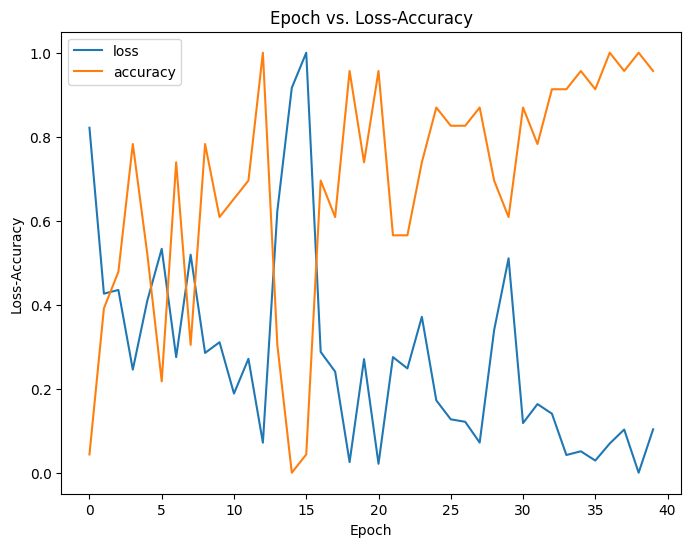

In [82]:
accuracy = (results["training_accuracy"]-np.min(results["training_accuracy"])) / (np.max(results["training_accuracy"])-np.min(results["training_accuracy"]))
loss = (results["training_loss"]-np.min(results["training_loss"])) / (np.max(results["training_loss"])-np.min(results["training_loss"]))

plt.figure(figsize=(8, 6))
plt.plot(loss, label="loss")
plt.plot(accuracy, label="accuracy")
plt.ylabel("Loss-Accuracy")
plt.xlabel("Epoch")
plt.title("Epoch vs. Loss-Accuracy")
plt.legend()
plt.show()

<h3>Creating a multiclass classifier using TensorFlow keras Functional API</h3>*

In [165]:
def multiclass_classifier(input_shape):

    input_size = tf.keras.layers.Input(shape=input_shape)

    Z1 = tf.keras.layers.Conv2D(filters=8, kernel_size=(3, 3), strides=(1, 1), padding="same")(input_size)
    A1 = tf.keras.layers.ReLU()(Z1)
    P1 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding="same")(A1)
    Z2 = tf.keras.layers.Conv2D(filters=20, kernel_size=(7, 7), strides=(2, 2), padding="same")(P1)
    P2 = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding="same")(Z2)
    A2 = tf.keras.layers.ReLU()(P2)
    F = tf.keras.layers.Flatten()(A2)
    FC1 = tf.keras.layers.Dense(units=20, activation="relu")(F)
    FC2 = tf.keras.layers.Dense(units=6, activation="softmax")(FC1)

    model = tf.keras.Model(inputs=input_size, outputs=FC2)

    return model   

In [166]:
model = multiclass_classifier((64, 64, 3))
model.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 64, 64, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 20)     │         7,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 8, 8, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 8, 8, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 20)             │        25,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 6)              │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,830 (132.15 KB)

 Trainable params: 33,830 (132.15 KB)

 Non-trainable params: 0 (0.00 B)

In [167]:
def train(model, X_train, Y_train, X_test, Y_test, epochs=100, learning_rate=1e-5, batch_size=16, optimizer="adam"):

    Y_train = tf.keras.utils.to_categorical(Y_train, num_classes=6)
    Y_test = tf.keras.utils.to_categorical(Y_test, num_classes=6)
    print(Y_test.shape)
    print(Y_train.shape)

    model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
    model.summary()
    train_data = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).batch(batch_size)
    test_data = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(batch_size)

    history = model.fit(train_data, epochs=epochs, validation_data=test_data)

    return history

<h4>Train the Model</h4>

In [168]:
train_data = h5py.File("/home/samani/Documents/projects/deep-learning/data/train_signs.h5", "r")
test_data = h5py.File("/home/samani/Documents/projects/deep-learning/data/test_signs.h5", "r")

In [169]:
print(train_data.keys())
print(test_data.keys())

<KeysViewHDF5 ['list_classes', 'train_set_x', 'train_set_y']>
<KeysViewHDF5 ['list_classes', 'test_set_x', 'test_set_y']>


In [170]:
print(train_data["list_classes"])

<HDF5 dataset "list_classes": shape (6,), type "<i8">


In [171]:
X_train = train_data["train_set_x"]
X_test = test_data["test_set_x"]
Y_train = train_data["train_set_y"]
Y_test = test_data["test_set_y"]

In [172]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(1080, 64, 64, 3)
(1080,)
(120, 64, 64, 3)
(120,)


In [173]:
X_train = np.array(list(X_train))
X_test = np.array(list(X_test))

X_train = X_train / 255.
X_test = X_test / 255.

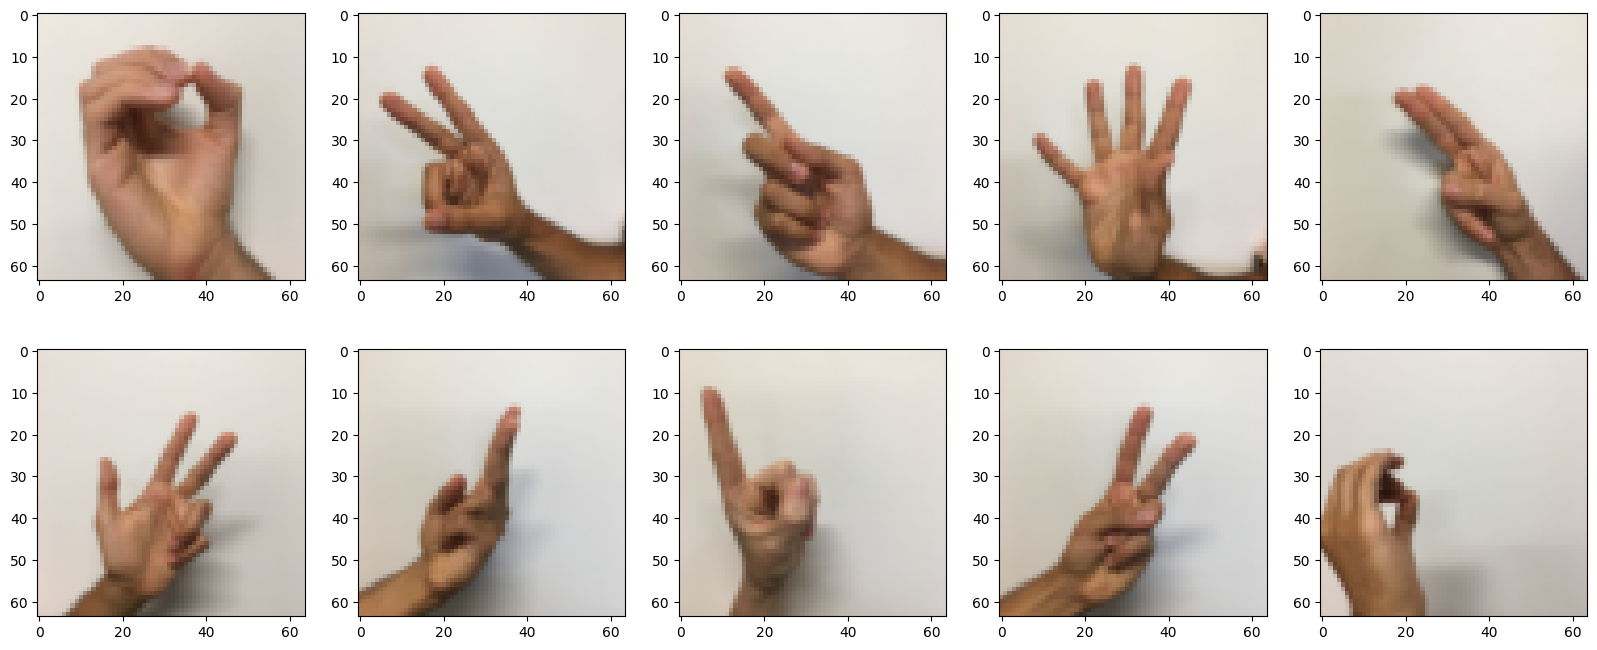

In [174]:
plt.figure(figsize=(20, 8))
plt.subplot(2, 5, 1)
imshow(X_train[1])
plt.subplot(2, 5, 2)
imshow(X_train[6])
plt.subplot(2, 5, 3)
imshow(X_train[8])
plt.subplot(2, 5, 4)
imshow(X_train[12])
plt.subplot(2, 5, 5)
imshow(X_train[14])
plt.subplot(2, 5, 6)
imshow(X_train[98])
plt.subplot(2, 5, 7)
imshow(X_train[57])
plt.subplot(2, 5, 8)
imshow(X_train[123])
plt.subplot(2, 5, 9)
imshow(X_train[187])
plt.subplot(2, 5, 10)
imshow(X_train[567])
plt.show()

In [175]:
history = train(model=model, X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test, epochs=100, learning_rate=1e-2, batch_size=32, optimizer="adam")

(120, 6)
(1080, 6)


Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 64, 64, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 64, 64, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 20)     │         7,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 8, 8, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 8, 8, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 20)             │        25,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 6)              │           126 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,830 (132.15 KB)

 Trainable params: 33,830 (132.15 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.1821 - loss: 1.7875 - val_accuracy: 0.2583 - val_loss: 1.7545
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2984 - loss: 1.7277 - val_accuracy: 0.3083 - val_loss: 1.6534
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3948 - loss: 1.5736 - val_accuracy: 0.4417 - val_loss: 1.4790
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4430 - loss: 1.3688 - val_accuracy: 0.4500 - val_loss: 1.3224
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4977 - loss: 1.2022 - val_accuracy: 0.5083 - val_loss: 1.2229
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5606 - loss: 1.1061 - val_accuracy: 0.5500 - val_loss: 1.1284
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5632 - loss: 1.0442 - val_accuracy: 0.5583 - val_loss: 1.0800
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5992 - loss: 0.9923 - val_accuracy: 0.

In [177]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


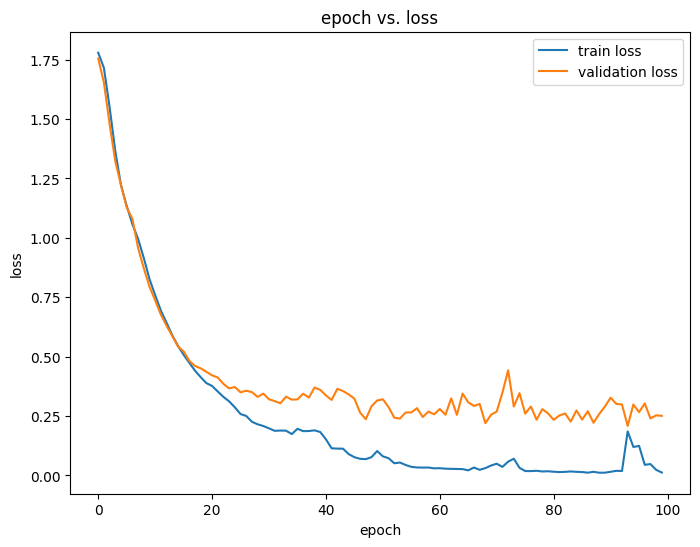

In [178]:
plt.figure(figsize=(8, 6))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("epoch vs. loss")
plt.legend()
plt.show()

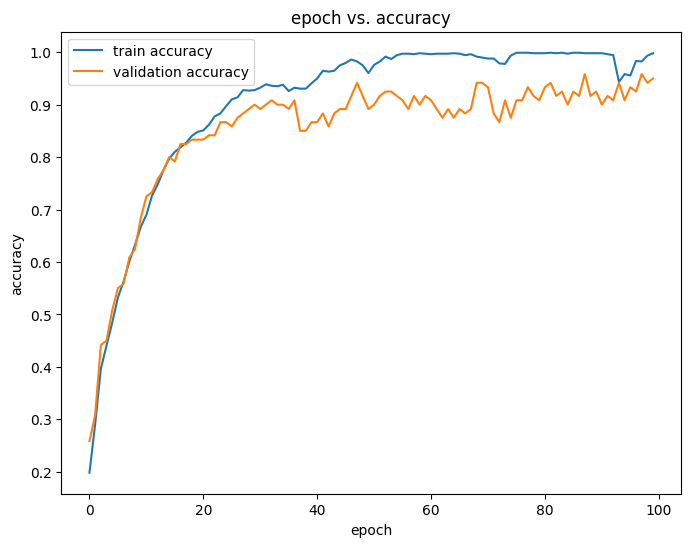

In [179]:
plt.figure(figsize=(8, 6))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("epoch vs. accuracy")
plt.legend()
plt.show()